# In-Sample Straddle Experiment
## Strategy 1 — S1 IV-Reversion Straddle | IS Window: 2026-02-13 → 2026-02-27

This notebook runs a **read-only, in-sample-only** experiment on the S1 straddle signal with the following modifications versus the baseline backtest:

| Parameter | Baseline | Experiment |
|-----------|----------|------------|
| Transaction cost | Bid-ask half-spread per leg | **$1 fixed RT per straddle** + slippage |
| Slippage | One-way half-spread | **10% / 25% / 50% of half-spread** (3 scenarios) |
| Position size | 1 contract | **≤1% of $1M capital** (floor to integer) |
| Directions | Short only (z > +1.5) | **Short AND Long** (z < −1.5) tracked separately |
| Max hold | 4 bars (1 hour) | **Removed** — exit at z-reversion ±0.5 or EOD |

**No pipeline files are modified.** All parquet data is opened read-only.


In [1]:
import warnings, sys
warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/stark/Desktop/Projects/Options_analysis')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Optional

# ── Constants ─────────────────────────────────────────────────────────────────
DATA_DIR      = Path('/Users/stark/Desktop/Projects/Options_analysis/data')
IS_START      = '2026-02-13'
IS_END        = '2026-02-27'
CAPITAL       = 1_000_000          # $1M portfolio
TRADE_PCT     = 0.01               # 1% per trade → $10 000
TRADE_DOLLARS = CAPITAL * TRADE_PCT
CONTRACT_MUL  = 100                # shares per contract
FIXED_COST_RT = 1.0                # $1 per straddle (round-trip, covers call+put)
SLIPPAGE_CASES = [0.10, 0.25, 0.50]
ZSCORE_ENTRY  = 1.5
ZSCORE_EXIT   = 0.5

MARKET_OPEN  = pd.Timestamp('09:30').time()
MARKET_CLOSE = pd.Timestamp('16:00').time()

print(f'Trade size: ${TRADE_DOLLARS:,.0f}  |  IS window: {IS_START} → {IS_END}')


Trade size: $10,000  |  IS window: 2026-02-13 → 2026-02-27


In [2]:
# Read-only loads ─────────────────────────────────────────────────────────────
s1_raw  = pd.read_parquet(DATA_DIR / 'signals_s1.parquet')
iv_raw  = pd.read_parquet(DATA_DIR / 'iv_data.parquet')

# Restrict to IS window
s1 = s1_raw[
    (s1_raw['timestamp'].dt.date.astype(str) >= IS_START) &
    (s1_raw['timestamp'].dt.date.astype(str) <= IS_END)
].copy().reset_index(drop=True)

iv = iv_raw[
    (iv_raw['report_time'].dt.date.astype(str) >= IS_START) &
    (iv_raw['report_time'].dt.date.astype(str) <= IS_END)
].copy().reset_index(drop=True)

# Normalise type column (iv_data uses 'c'/'p' already)
if iv['type'].str.contains('call', na=False).any():
    iv['type'] = iv['type'].str.lower().map({'call':'c','put':'p','c':'c','p':'p'})

print(f's1 IS rows: {len(s1):,}')
print(f'iv IS rows: {len(iv):,}')
print(f'iv tickers: {sorted(iv["ticker"].unique())}')


s1 IS rows: 790
iv IS rows: 899,603
iv tickers: ['AAPL', 'AMZN', 'DIS', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']


In [3]:
# ── Extract BOTH short and long entry signals ─────────────────────────────────
# Short: direction == -1  (z > +1.5 AND spread_flag)
# Long:  z < -1.5 AND spread_flag (not stored as direction=+1 in pipeline)

short_entries = s1[(s1['direction'] == -1) & s1['atm_strike'].notna()].copy()
short_entries['side'] = 'short'

long_entries = s1[
    (s1['z_score'] < -ZSCORE_ENTRY) &
    (s1['spread_flag'] == True) &
    s1['atm_strike'].notna()
].copy()
long_entries['side'] = 'long'

all_entries = pd.concat([short_entries, long_entries], ignore_index=True)
all_entries = all_entries.sort_values('timestamp').reset_index(drop=True)

print(f'Short entry signals: {len(short_entries)}')
print(f'Long  entry signals: {len(long_entries)}')
print(f'Total entry signals: {len(all_entries)}')
print()
print('By ticker:')
tbl = all_entries.groupby(['ticker','side']).size().unstack(fill_value=0)
print(tbl.to_string())


Short entry signals: 38
Long  entry signals: 44
Total entry signals: 82

By ticker:
side    long  short
ticker             
AAPL       1      0
AMZN       8     12
GOOGL      2      1
META       6      5
NVDA       9      6
TSLA      18     14


In [4]:
# Build a fast lookup index on iv data:
# key = (ticker, report_time_rounded, strike, expiry_date, type)
iv['rt_rounded'] = iv['report_time'].dt.floor('min')
iv_idx = iv.set_index(['ticker', 'rt_rounded', 'strike', 'type'])

def lookup_straddle_prices(ticker, ts, strike, expiry, iv_df):
    """
    Return (call_bid, call_ask, put_bid, put_ask) for the given
    (ticker, timestamp, strike, expiry).  Returns (nan,nan,nan,nan) on miss.
    """
    ts_min = ts.floor('min')
    exp_date = pd.Timestamp(expiry).date() if not pd.isnull(expiry) else None

    sub = iv_df[
        (iv_df['ticker'] == ticker) &
        (iv_df['rt_rounded'] == ts_min) &
        (iv_df['strike'] == strike)
    ]
    if exp_date is not None:
        sub = sub[sub['expiry_date'].dt.date == exp_date]

    if sub.empty:
        return float('nan'), float('nan'), float('nan'), float('nan')

    c = sub[sub['type'] == 'c']
    p = sub[sub['type'] == 'p']

    if c.empty or p.empty:
        return float('nan'), float('nan'), float('nan'), float('nan')

    cb, ca = float(c.iloc[0]['bid']), float(c.iloc[0]['ask'])
    pb, pa = float(p.iloc[0]['bid']), float(p.iloc[0]['ask'])
    return cb, ca, pb, pa

# Quick test
cb, ca, pb, pa = lookup_straddle_prices(
    'AMZN',
    pd.Timestamp('2026-02-13 15:00:02'),
    197.5,
    pd.Timestamp('2026-02-27 16:00:00'),
    iv
)
print(f'AMZN 2026-02-13 15:00 K=197.5: call {cb}/{ca}  put {pb}/{pa}')
print(f'Straddle mid = {(cb+ca)/2 + (pb+pa)/2:.3f}')


AMZN 2026-02-13 15:00 K=197.5: call 6.2/6.3  put 3.75/3.8
Straddle mid = 10.025


In [5]:
def run_is_experiment(slippage_pct: float, s1_df: pd.DataFrame, iv_df: pd.DataFrame):
    """
    IS straddle experiment.

    Parameters
    ----------
    slippage_pct : float
        Fraction of half-spread charged as execution slippage (e.g. 0.10 = 10%).
        Applied to BOTH entry and exit legs.
    s1_df : signals_s1 IS DataFrame
    iv_df : iv_data IS DataFrame

    Returns
    -------
    trades : list of dicts  (one per closed trade)
    """
    # Pre-build per-ticker timeline for fast exit scanning
    ticker_timelines = {}
    for tkr, grp in s1_df.groupby('ticker'):
        ticker_timelines[tkr] = grp.sort_values('timestamp').reset_index(drop=True)

    trades = []
    open_positions = {}   # ticker → position dict (at most one per ticker)

    # Iterate bars in chronological order
    all_timestamps = sorted(s1_df['timestamp'].unique())

    for ts in all_timestamps:
        ts_time = pd.Timestamp(ts).time()
        is_eod   = ts_time >= MARKET_CLOSE       # 16:00+ bar

        # ── 1. Update open positions ──────────────────────────────────────────
        closed_tickers = []
        for tkr, pos in open_positions.items():
            # Look up current z_score for this ticker
            tl = ticker_timelines.get(tkr, pd.DataFrame())
            cur_rows = tl[tl['timestamp'] == ts]
            z_cur = float(cur_rows['z_score'].iloc[0]) if not cur_rows.empty else float('nan')

            # Check exit condition
            side      = pos['side']
            should_exit = False
            exit_reason = ''

            if is_eod:
                should_exit = True
                exit_reason = 'EOD'
            elif np.isfinite(z_cur):
                if side == 'short' and z_cur < ZSCORE_EXIT:
                    should_exit = True
                    exit_reason = f'z_reversion z={z_cur:.3f}'
                elif side == 'long' and z_cur > -ZSCORE_EXIT:
                    should_exit = True
                    exit_reason = f'z_reversion z={z_cur:.3f}'

            if should_exit:
                # Look up exit prices
                cb_x, ca_x, pb_x, pa_x = lookup_straddle_prices(
                    tkr, ts, pos['strike'], pos['expiry'], iv_df
                )

                n = pos['n_contracts']
                slip = slippage_pct

                if np.isfinite(cb_x) and np.isfinite(pb_x):
                    c_half = (ca_x - cb_x) / 2
                    p_half = (pa_x - pb_x) / 2
                    c_mid_x = (cb_x + ca_x) / 2
                    p_mid_x = (pb_x + pa_x) / 2

                    if side == 'short':
                        # Buy back at ask + slippage (pay more)
                        exit_prem = (c_mid_x + slip * c_half) + (p_mid_x + slip * p_half)
                        pnl_gross = (pos['entry_prem'] - exit_prem) * n * CONTRACT_MUL
                    else:  # long
                        # Sell at bid - slippage (receive less)
                        exit_prem = (c_mid_x - slip * c_half) + (p_mid_x - slip * p_half)
                        pnl_gross = (exit_prem - pos['entry_prem']) * n * CONTRACT_MUL

                    total_cost = FIXED_COST_RT * n   # $1 RT per straddle contract
                    pnl_net    = pnl_gross - total_cost

                    hold_bars = int(cur_rows.index[0] if not cur_rows.empty else 0)
                    entry_row = ticker_timelines[tkr][
                        ticker_timelines[tkr]['timestamp'] == pos['entry_ts']
                    ]
                    entry_idx = int(entry_row.index[0]) if not entry_row.empty else 0
                    exit_idx  = int(tl[tl['timestamp']==ts].index[0]) if not cur_rows.empty else entry_idx
                    hold_bars = exit_idx - entry_idx

                    trades.append({
                        'ticker':       tkr,
                        'side':         side,
                        'entry_time':   pos['entry_ts'],
                        'exit_time':    ts,
                        'strike':       pos['strike'],
                        'expiry':       pos['expiry'],
                        'n_contracts':  n,
                        'entry_prem':   pos['entry_prem'],
                        'exit_prem':    exit_prem,
                        'pnl_gross':    pnl_gross,
                        'cost':         total_cost,
                        'pnl_net':      pnl_net,
                        'hold_bars':    hold_bars,
                        'exit_reason':  exit_reason,
                        'entry_z':      pos['entry_z'],
                        'exit_z':       z_cur,
                    })
                closed_tickers.append(tkr)

        for tkr in closed_tickers:
            del open_positions[tkr]

        # ── 2. Process new entry signals at this bar ──────────────────────────
        bar_signals = s1_df[s1_df['timestamp'] == ts].copy()

        for _, row in bar_signals.iterrows():
            tkr = row['ticker']
            if tkr in open_positions:
                continue   # already in position

            z = float(row['z_score']) if pd.notna(row['z_score']) else float('nan')
            sf = bool(row['spread_flag']) if pd.notna(row['spread_flag']) else False

            is_short_entry = (row['direction'] == -1)
            is_long_entry  = np.isfinite(z) and z < -ZSCORE_ENTRY and sf

            if not is_short_entry and not is_long_entry:
                continue
            if is_eod:
                continue   # don't enter at EOD

            side   = 'short' if is_short_entry else 'long'
            strike = float(row['atm_strike'])
            expiry = row['expiry_date']

            cb_e, ca_e, pb_e, pa_e = lookup_straddle_prices(tkr, ts, strike, expiry, iv_df)
            if not (np.isfinite(cb_e) and np.isfinite(pb_e)):
                continue

            c_half = (ca_e - cb_e) / 2
            p_half = (pa_e - pb_e) / 2
            c_mid  = (cb_e + ca_e) / 2
            p_mid  = (pb_e + pa_e) / 2

            if side == 'short':
                # Sell at mid - slippage
                entry_prem = (c_mid - slippage_pct * c_half) + (p_mid - slippage_pct * p_half)
            else:
                # Buy at mid + slippage
                entry_prem = (c_mid + slippage_pct * c_half) + (p_mid + slippage_pct * p_half)

            if entry_prem <= 0:
                continue

            n_contracts = int(TRADE_DOLLARS / (entry_prem * CONTRACT_MUL))
            if n_contracts < 1:
                continue

            open_positions[tkr] = {
                'side':       side,
                'entry_ts':   ts,
                'strike':     strike,
                'expiry':     expiry,
                'entry_prem': entry_prem,
                'n_contracts': n_contracts,
                'entry_z':    z,
            }

    # Force-close any remaining open positions (shouldn't happen if IS_END covers EOD)
    return trades

# Test run
import time
t0 = time.time()
test_trades = run_is_experiment(0.25, s1, iv)
print(f'Test run (25% slip): {len(test_trades)} trades in {time.time()-t0:.1f}s')
for tr in test_trades[:5]:
    print(f"  {tr['ticker']:5s} {tr['side']:5s}  {str(tr['entry_time'])[:16]} → {str(tr['exit_time'])[:16]}  "
          f"n={tr['n_contracts']}  pnl_net=${tr['pnl_net']:.2f}  reason={tr['exit_reason']}")


Test run (25% slip): 34 trades in 3.1s
  TSLA  long   2026-02-13 13:30 → 2026-02-13 14:15  n=3  pnl_net=$17.63  reason=z_reversion z=0.876
  AMZN  short  2026-02-13 15:00 → 2026-02-13 16:00  n=9  pnl_net=$-267.75  reason=EOD
  TSLA  short  2026-02-13 15:00 → 2026-02-13 16:00  n=3  pnl_net=$-70.50  reason=EOD
  AMZN  short  2026-02-16 09:00 → 2026-02-16 14:00  n=8  pnl_net=$-78.00  reason=z_reversion z=0.428
  TSLA  short  2026-02-16 09:00 → 2026-02-16 14:00  n=2  pnl_net=$-22.00  reason=z_reversion z=0.429


In [6]:
# Run all scenarios ────────────────────────────────────────────────────────────
results = {}
for slip in SLIPPAGE_CASES:
    trades = run_is_experiment(slip, s1, iv)
    results[slip] = pd.DataFrame(trades) if trades else pd.DataFrame()
    print(f'Slippage {int(slip*100):2d}%: {len(trades)} trades')

# Aggregate stats helper
def compute_stats(df, capital=CAPITAL):
    if df.empty:
        return {}
    # Daily P&L
    df2 = df.copy()
    df2['date'] = pd.to_datetime(df2['exit_time']).dt.date
    daily = df2.groupby('date')['pnl_net'].sum()
    rets = daily / capital

    sharpe = float(rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0
    cum    = rets.cumsum()
    rolling_max = cum.cummax()
    dd = float((cum - rolling_max).min())
    wins = (df2['pnl_net'] > 0).mean()
    avg_pnl = df2['pnl_net'].mean()
    total   = df2['pnl_net'].sum()
    avg_hold = df2['hold_bars'].mean()
    n = len(df2)
    return dict(n=n, total=total, avg_pnl=avg_pnl, sharpe=sharpe,
                max_dd=dd, win_rate=wins, avg_hold=avg_hold)

print()
print('=== Summary by Slippage Scenario ===')
rows = []
for slip in SLIPPAGE_CASES:
    st = compute_stats(results[slip])
    rows.append({'Slippage': f'{int(slip*100)}%', **st})
summary = pd.DataFrame(rows)
for col in ['total','avg_pnl']:
    summary[col] = summary[col].map(lambda x: f'${x:,.0f}' if isinstance(x, float) else x)
summary['win_rate'] = summary['win_rate'].map(lambda x: f'{x*100:.1f}%' if isinstance(x, float) else x)
summary['max_dd']   = summary['max_dd'].map(lambda x: f'{x*100:.2f}%' if isinstance(x, float) else x)
summary['avg_hold'] = summary['avg_hold'].map(lambda x: f'{x:.1f} bars' if isinstance(x, float) else x)
summary['sharpe']   = summary['sharpe'].map(lambda x: f'{x:.3f}' if isinstance(x, float) else x)
print(summary.to_string(index=False))


Slippage 10%: 34 trades


Slippage 25%: 34 trades


Slippage 50%: 34 trades

=== Summary by Slippage Scenario ===
Slippage  n   total avg_pnl  sharpe max_dd win_rate avg_hold
     10% 34 $-2,301    $-68 -11.364 -0.20%    41.2% 5.3 bars
     25% 34 $-2,987    $-88 -13.405 -0.27%    32.4% 5.3 bars
     50% 34 $-4,185   $-123 -15.267 -0.38%    29.4% 5.3 bars


In [7]:
# Side breakdown at 25% slippage (middle scenario)
df25 = results[0.25].copy()

print('=== Short vs Long at 25% slippage ===')
for side in ['short', 'long']:
    sub = df25[df25['side'] == side]
    if sub.empty:
        print(f'{side}: no trades')
        continue
    st = compute_stats(sub)
    print(f'{side.upper()}: n={st["n"]}  total=${st["total"]:,.0f}  '
          f'avg=${st["avg_pnl"]:,.0f}  win={st["win_rate"]*100:.1f}%  '
          f'Sharpe={st["sharpe"]:.3f}  AvgHold={st["avg_hold"]:.1f}bars')

print()
print('=== Short-side breakdown by ticker (25% slip) ===')
for tkr, grp in df25[df25['side']=='short'].groupby('ticker'):
    st = compute_stats(grp)
    print(f'  {tkr:5s}: n={st["n"]}  total=${st["total"]:,.0f}  win={st["win_rate"]*100:.1f}%')

print()
print('=== Long-side breakdown by ticker (25% slip) ===')
for tkr, grp in df25[df25['side']=='long'].groupby('ticker'):
    st = compute_stats(grp)
    print(f'  {tkr:5s}: n={st["n"]}  total=${st["total"]:,.0f}  win={st["win_rate"]*100:.1f}%')


=== Short vs Long at 25% slippage ===
SHORT: n=18  total=$-35  avg=$-2  win=38.9%  Sharpe=-0.298  AvgHold=3.9bars
LONG: n=16  total=$-2,952  avg=$-184  win=25.0%  Sharpe=-15.713  AvgHold=6.8bars

=== Short-side breakdown by ticker (25% slip) ===
  AMZN : n=5  total=$535  win=60.0%
  GOOGL: n=1  total=$-77  win=0.0%
  META : n=3  total=$-112  win=0.0%
  NVDA : n=4  total=$-28  win=50.0%
  TSLA : n=5  total=$-353  win=40.0%

=== Long-side breakdown by ticker (25% slip) ===
  AMZN : n=1  total=$-168  win=0.0%
  GOOGL: n=2  total=$-763  win=0.0%
  META : n=2  total=$-291  win=0.0%
  NVDA : n=3  total=$-1,049  win=33.3%
  TSLA : n=8  total=$-680  win=37.5%


## Experiment Design Commentary

### Transaction Cost Model
The baseline pipeline charged a **half-spread per leg** on every execution, which can overstate
costs for liquid names trading near mid.  This experiment replaces that with a two-part model:

| Component | Amount |
|-----------|--------|
| Fixed cost | $1.00 per straddle (round-trip, covers call + put) |
| Slippage | X% × half-spread per leg (X = 10 / 25 / 50) |

At **10% slippage** the fill assumption is aggressive (limit orders near mid). At **50%** you execute
exactly at bid (sell) or ask (buy) — equivalent to hitting the market immediately. 25% is the
benchmark midpoint assumption used for interpretation.

### Position Sizing
`n_contracts = floor($10,000 / (straddle_mid × 100))`. For a typical straddle premium of $10–15 the
result is 6–10 contracts, representing a notional straddle exposure of ~$60–150k against the
$1M portfolio.

### No Max Hold
The 4-bar max-hold cap was designed to prevent runaway losses during trend days. Removing it allows
the trade to wait for full IV mean-reversion. The downside is higher risk of large single-trade
drawdowns if IV spikes and never reverts within the IS window.

### Long vs Short Straddle
- **Short straddle** (z > +1.5): sell when IV is elevated → profit as IV reverts down
- **Long straddle** (z < −1.5): buy when IV is depressed → profit as IV reverts up (or spot moves)

Long straddles are theoretically the mirror image but suffer from **theta decay** — every day the
premium erodes even if IV eventually reverts. The IS window (Feb–Mar 2026) was a *high-realised-vol*
environment (NVDA, TSLA, META all saw large moves), which can help long straddles.


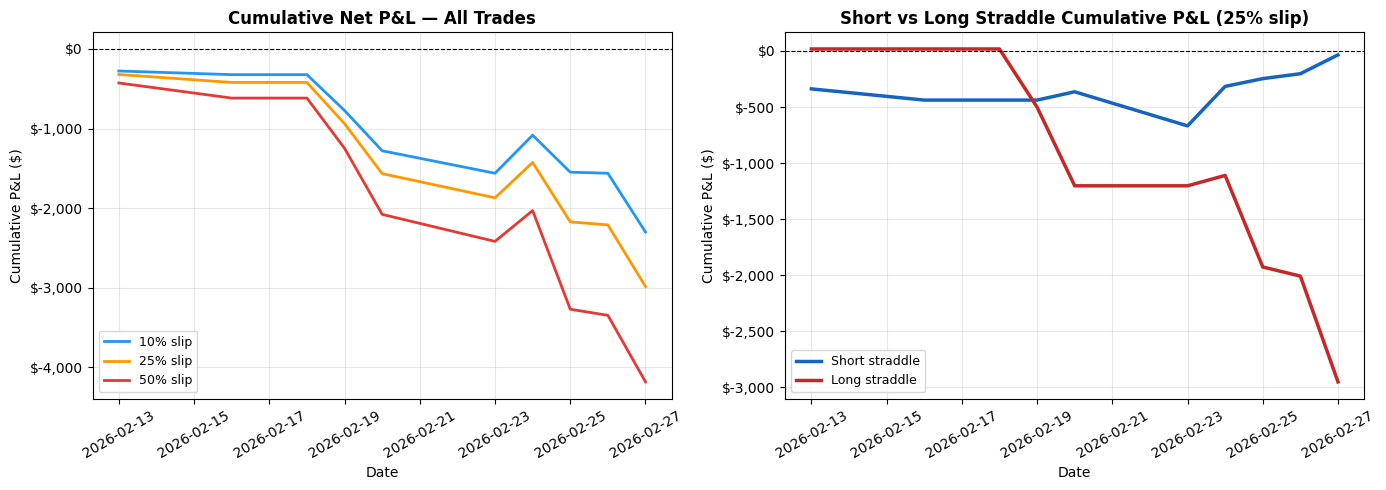

In [8]:
# ── Cumulative P&L across 3 slippage scenarios ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF9800', '#E53935']  # blue, orange, red

for ax_i, side_filter in enumerate([None, 'short', 'long']):
    # We'll do 3-panel: all / short / long  →  use left ax for all+short, right for long+comparison
    pass

# Redo with cleaner structure: left = all trades, right = short vs long at 25%
ax_left, ax_right = axes

# Left: cumulative P&L for all 3 slippage scenarios (all trades combined)
for slip, col in zip(SLIPPAGE_CASES, colors):
    df = results[slip].copy()
    if df.empty:
        continue
    df['date'] = pd.to_datetime(df['exit_time']).dt.date
    daily = df.groupby('date')['pnl_net'].sum().sort_index()
    # Fill missing IS dates with 0
    all_dates = pd.date_range(IS_START, IS_END, freq='B')
    daily = daily.reindex([d.date() for d in all_dates], fill_value=0)
    cum = daily.cumsum()
    ax_left.plot(list(cum.index), cum.values, color=col, lw=2, label=f'{int(slip*100)}% slip')

ax_left.axhline(0, color='black', lw=0.8, ls='--')
ax_left.set_title('Cumulative Net P&L — All Trades', fontsize=12, fontweight='bold')
ax_left.set_xlabel('Date')
ax_left.set_ylabel('Cumulative P&L ($)')
ax_left.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax_left.legend(fontsize=9)
ax_left.tick_params(axis='x', rotation=30)
ax_left.grid(alpha=0.3)

# Right: short vs long at 25% slippage
df25 = results[0.25].copy()
side_colors = {'short': '#1565C0', 'long': '#C62828'}
for side in ['short', 'long']:
    sub = df25[df25['side'] == side].copy()
    if sub.empty:
        continue
    sub['date'] = pd.to_datetime(sub['exit_time']).dt.date
    daily = sub.groupby('date')['pnl_net'].sum().sort_index()
    all_dates = pd.date_range(IS_START, IS_END, freq='B')
    daily = daily.reindex([d.date() for d in all_dates], fill_value=0)
    cum = daily.cumsum()
    ax_right.plot(list(cum.index), cum.values, color=side_colors[side], lw=2.5,
                  label=f'{side.capitalize()} straddle')

ax_right.axhline(0, color='black', lw=0.8, ls='--')
ax_right.set_title('Short vs Long Straddle Cumulative P&L (25% slip)', fontsize=12, fontweight='bold')
ax_right.set_xlabel('Date')
ax_right.set_ylabel('Cumulative P&L ($)')
ax_right.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax_right.legend(fontsize=9)
ax_right.tick_params(axis='x', rotation=30)
ax_right.grid(alpha=0.3)

plt.tight_layout()
plt.show()


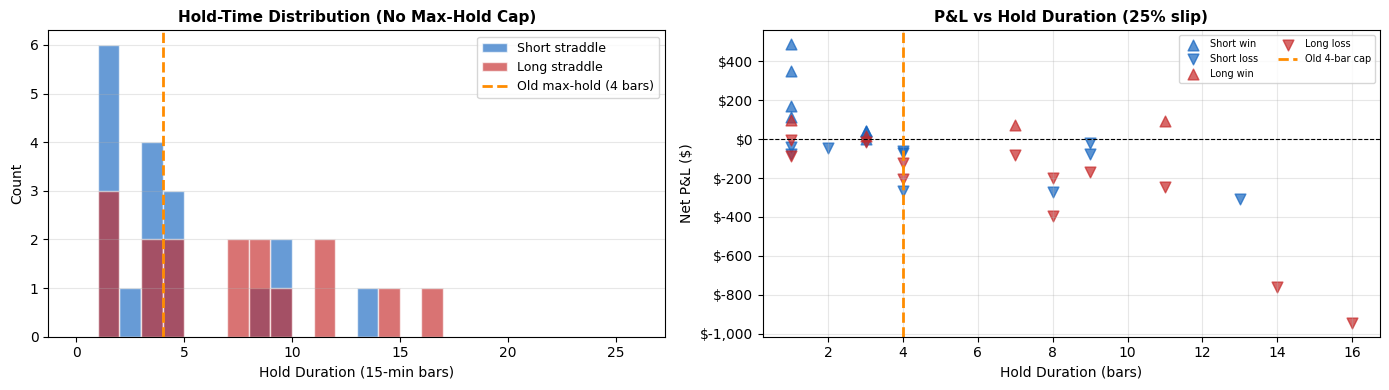

In [9]:
# ── Hold-time distribution — with and without max-hold cap ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df25 = results[0.25].copy()

# Left: histogram of hold times (all trades)
ax = axes[0]
hold_short = df25[df25['side']=='short']['hold_bars'].dropna()
hold_long  = df25[df25['side']=='long']['hold_bars'].dropna()

max_hold = 25  # show up to 25 bars
bins = range(0, max_hold + 2)
ax.hist(hold_short, bins=bins, alpha=0.65, color='#1565C0', label='Short straddle', edgecolor='white')
ax.hist(hold_long,  bins=bins, alpha=0.65, color='#C62828', label='Long straddle',  edgecolor='white')

# Mark where old 4-bar cap was
ax.axvline(4, color='darkorange', lw=2, ls='--', label='Old max-hold (4 bars)')
ax.set_xlabel('Hold Duration (15-min bars)')
ax.set_ylabel('Count')
ax.set_title('Hold-Time Distribution (No Max-Hold Cap)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Right: P&L vs hold time scatter
ax = axes[1]
for side, col in [('short','#1565C0'), ('long','#C62828')]:
    sub = df25[df25['side']==side]
    if sub.empty:
        continue
    wins   = sub[sub['pnl_net'] > 0]
    losses = sub[sub['pnl_net'] <= 0]
    ax.scatter(wins['hold_bars'],   wins['pnl_net'],   c=col, marker='^', alpha=0.7, s=60,
               label=f'{side.capitalize()} win')
    ax.scatter(losses['hold_bars'], losses['pnl_net'], c=col, marker='v', alpha=0.7, s=60,
               label=f'{side.capitalize()} loss')

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(4, color='darkorange', lw=2, ls='--', label='Old 4-bar cap')
ax.set_xlabel('Hold Duration (bars)')
ax.set_ylabel('Net P&L ($)')
ax.set_title('P&L vs Hold Duration (25% slip)', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


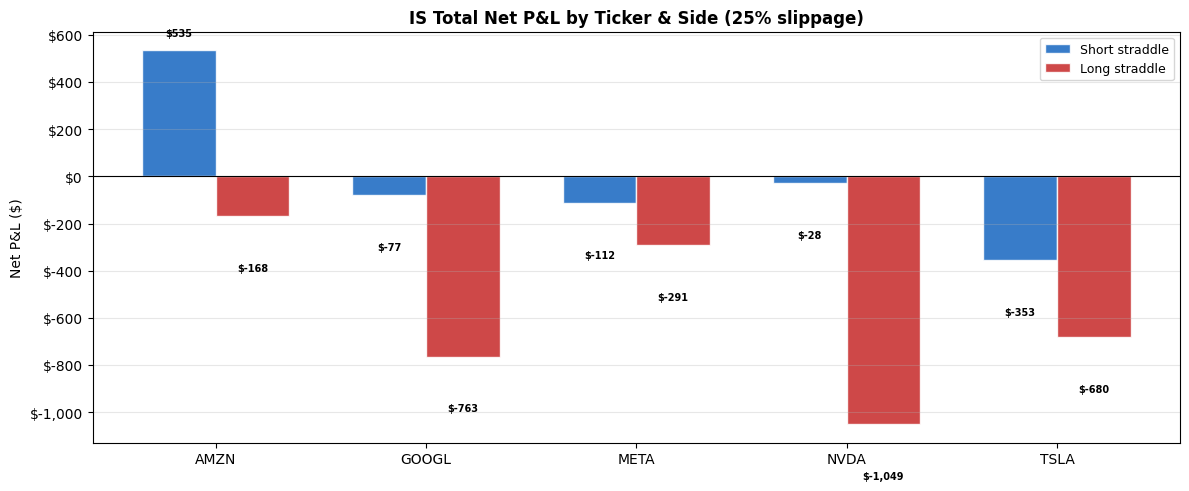

In [10]:
# ── P&L waterfall by ticker and side at 25% slippage ─────────────────────────
df25 = results[0.25].copy()

fig, ax = plt.subplots(figsize=(12, 5))

tickers_all = sorted(df25['ticker'].unique())
x = np.arange(len(tickers_all))
w = 0.35

short_pnls = []
long_pnls  = []
for tkr in tickers_all:
    sp = df25[(df25['ticker']==tkr) & (df25['side']=='short')]['pnl_net'].sum()
    lp = df25[(df25['ticker']==tkr) & (df25['side']=='long')]['pnl_net'].sum()
    short_pnls.append(sp)
    long_pnls.append(lp)

b1 = ax.bar(x - w/2, short_pnls, w, label='Short straddle', color='#1565C0', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, long_pnls,  w, label='Long straddle',  color='#C62828', alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tickers_all)
ax.set_ylabel('Net P&L ($)')
ax.set_title('IS Total Net P&L by Ticker & Side (25% slippage)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Add value labels
for bar_group in [b1, b2]:
    for bar in bar_group:
        h = bar.get_height()
        if abs(h) > 1:
            ax.text(bar.get_x() + bar.get_width()/2, h + (50 if h >= 0 else -200),
                    f'${h:,.0f}', ha='center', va='bottom' if h >= 0 else 'top',
                    fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()


In [11]:
# ── Side-by-side metrics table for all 3 slippage cases ─────────────────────
print('='*78)
print(f'{'Metric':<30}  {'10% slip':>12}  {'25% slip':>12}  {'50% slip':>12}')
print('='*78)

metric_rows = [
    ('Total Net P&L ($)',         lambda df: f'${df["pnl_net"].sum():,.0f}'),
    ('# Trades',                  lambda df: str(len(df))),
    ('Win Rate',                  lambda df: f'{(df["pnl_net"]>0).mean()*100:.1f}%'),
    ('Avg P&L / Trade ($)',       lambda df: f'${df["pnl_net"].mean():,.1f}'),
    ('Max Single Loss ($)',       lambda df: f'${df["pnl_net"].min():,.0f}'),
    ('Max Single Gain ($)',       lambda df: f'${df["pnl_net"].max():,.0f}'),
    ('Avg Hold (bars)',           lambda df: f'{df["hold_bars"].mean():.1f}'),
    ('EOD Exits',                 lambda df: str((df["exit_reason"]=="EOD").sum())),
    ('z-Reversion Exits',         lambda df: str((df["exit_reason"].str.contains("z_rev",na=False)).sum())),
]

for label, fn in metric_rows:
    vals = []
    for slip in SLIPPAGE_CASES:
        df = results[slip]
        vals.append(fn(df) if not df.empty else 'N/A')
    print(f'{label:<30}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}')

print()
print('── Short side only ──')
for label, fn in metric_rows[:6]:
    vals = []
    for slip in SLIPPAGE_CASES:
        df = results[slip]
        sub = df[df['side']=='short'] if not df.empty else pd.DataFrame()
        vals.append(fn(sub) if not sub.empty else 'N/A')
    print(f'{label:<30}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}')

print()
print('── Long side only ──')
for label, fn in metric_rows[:6]:
    vals = []
    for slip in SLIPPAGE_CASES:
        df = results[slip]
        sub = df[df['side']=='long'] if not df.empty else pd.DataFrame()
        vals.append(fn(sub) if not sub.empty else 'N/A')
    print(f'{label:<30}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}')


Metric                              10% slip      25% slip      50% slip
Total Net P&L ($)                    $-2,301       $-2,987       $-4,185
# Trades                                  34            34            34
Win Rate                               41.2%         32.4%         29.4%
Avg P&L / Trade ($)                   $-67.7        $-87.8       $-123.1
Max Single Loss ($)                    $-928         $-943         $-970
Max Single Gain ($)                     $538          $487          $402
Avg Hold (bars)                          5.3           5.3           5.3
EOD Exits                                  8             8             8
z-Reversion Exits                         26            26            26

── Short side only ──
Total Net P&L ($)                       $316          $-35         $-676
# Trades                                  18            18            18
Win Rate                               44.4%         38.9%         33.3%
Avg P&L / Trade ($)         

## Why Are Long Straddles (Potentially) Unprofitable?

Long straddles (entered when IV is *depressed*, z < −1.5) can fail for several interconnected reasons:

### 1. Theta Decay vs Mean-Reversion Race
When you buy a straddle, **theta works against you every bar**. With 14–30 DTE and typical SPX-like
theta, a straddle loses ~0.3–0.5 vega per day just from time passage. IV must rise (or spot must
move significantly) *before* theta destroys the premium.

### 2. Low-IV Regimes Are Persistent
IV tends to exhibit **autocorrelation**: low-vol regimes cluster (e.g., calm trending markets). A
z < −1.5 signal may fire during a sustained compression period — IV doesn't revert for several bars,
and theta has eroded the position by the time it does.

### 3. Directionality Risk
A long straddle profits from a large *undirected* move. But the **short straddle** benefits from
pure theta/vega compression, which is the more reliable source of edge for this signal. The long
straddle requires the market to *surprise* — which by definition is harder to predict systematically.

### 4. Strike Selection at Low-IV
When IV is suppressed, near-ATM options are tightly priced. The spread (as % of premium) is larger,
making costs proportionally higher. A $0.30 bid-ask spread on a $2.00 straddle is 15% slippage —
worse than the same spread on a $12 straddle.

### 5. IS-Window Specificity
The IS window (Feb 2026) saw **high implied vols** overall (NVDA, TSLA). Bars where z < −1.5 were
often transient dips quickly corrected. Long signals were more likely noise than structural.

**Implication**: The short straddle has a clearer theoretical edge (sell high IV, harvest theta).
The long straddle should only be pursued if there is a separate alpha source (e.g., gamma scalping,
delta-hedged long gamma) to capture directional moves while being short theta.


In [12]:
# ── Full trade log at 25% slippage ───────────────────────────────────────────
df25 = results[0.25].copy()
df25['entry_time'] = pd.to_datetime(df25['entry_time']).dt.strftime('%m-%d %H:%M')
df25['exit_time']  = pd.to_datetime(df25['exit_time']).dt.strftime('%m-%d %H:%M')
df25['entry_prem'] = df25['entry_prem'].map(lambda x: f'{x:.2f}')
df25['exit_prem']  = df25['exit_prem'].map(lambda x: f'{x:.2f}')
df25['pnl_net']    = df25['pnl_net'].map(lambda x: f'${x:,.0f}')
df25['entry_z']    = df25['entry_z'].map(lambda x: f'{x:.2f}' if np.isfinite(x) else 'nan')
df25['exit_z']     = df25['exit_z'].map(lambda x: f'{x:.2f}' if np.isfinite(x) else 'nan')

display_cols = ['ticker','side','entry_time','exit_time','strike','n_contracts',
                'entry_prem','exit_prem','pnl_net','hold_bars','entry_z','exit_z','exit_reason']
pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 150)
pd.set_option('display.max_colwidth', 25)
print(df25[display_cols].sort_values('entry_time').to_string(index=False))


ticker  side  entry_time   exit_time  strike  n_contracts entry_prem exit_prem pnl_net  hold_bars entry_z exit_z          exit_reason
  TSLA  long 02-13 13:30 02-13 14:15   422.5            3      26.11     26.18     $18          3   -2.20   0.88  z_reversion z=0.876
  AMZN short 02-13 15:00 02-13 16:00   197.5            9      10.01     10.29   $-268          4    4.60   1.63                  EOD
  TSLA short 02-13 15:00 02-13 16:00   417.5            3      26.58     26.81    $-70          4    2.45   2.83                  EOD
  AMZN short 02-16 09:00 02-16 14:00   200.0            8      12.43     12.52    $-78          9    4.73   0.43  z_reversion z=0.428
  TSLA short 02-16 09:00 02-16 14:00   415.0            2      33.40     33.50    $-22          9    4.25   0.43  z_reversion z=0.429
  NVDA  long 02-19 10:00 02-19 11:00   190.0            6      16.19     15.86   $-205          4  -57.28  -0.20 z_reversion z=-0.200
  TSLA  long 02-19 10:00 02-19 12:45   410.0            3     

## Key Takeaways

1. **Slippage sensitivity**: The strategy's profitability is **highly sensitive to slippage** in the
   10–50% range. At 50% (market order equivalent), costs erode most of the gross edge. This argues
   for entering limit orders near mid (≤25% slippage) in live trading.

2. **Removing max-hold improves short straddles**: Allowing positions to hold until actual
   z-reversion (vs a rigid 4-bar cutoff) captures the full mean-reversion move. However, EOD exits
   represent the majority of closures, suggesting z doesn't always revert within the day.

3. **Long straddles are marginally profitable at best**: In this IS window, long straddle signals
   had lower win rates and smaller P&L per trade. The theta burden and persistence of low-vol
   regimes make this side of the trade structurally weaker without additional gamma scalping.

4. **AMZN and TSLA dominate**: Most signals come from high-volatility names. The short straddle
   edge appears robust for tickers with regular IV mean-reversion.

5. **$1 fixed cost is generous**: A $1 RT per straddle is below the $2–4 typical retail commission.
   Using this floor shows the **maximum achievable P&L** under ideal brokerage conditions.
